# Прогноз НАПРАВЛЕНИЯ цены BTC — 3 класса, часовые данные, горизонт 24ч

Метка в `t`: `ret = close[t+24]/close[t] − 1`; `+1` если `ret ≥ +2%`, `−1` если `ret ≤ −2%`, иначе `0`.

**Центральная исследовательская часть — сравнение ТРЁХ постановок** (один обучатель LightGBM, одни фичи/фолды/порог/бэктест):
- **A** — 3-классовый softmax;
- **B** — две независимые бинарные (up / down) + согласование;
- **C** — каскад gate→direction (варианты **c1** на реальной big-популяции и **c2** с OOF-весом gate — демонстрация selection bias).

Приоритеты: (1) нет утечек; (2) purged + embargoed **walk-forward**; (3) полный модуль метрик; (4) сравнение постановок.

> Тумблеры вверху: `REBUILD_DATA`, `TARGET_TYPE`, а также `config.QUICK_MODE` (мало trials / короткая история / меньше фолдов — для быстрого прогона). Полный прогон: `QUICK_MODE=False`, `REBUILD_DATA=True`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, time
from src import config, compute, data_io, features, labeling, validation, models, optimize, backtest, metrics, plotting

# версии
import sklearn, lightgbm, optuna, scipy, statsmodels, matplotlib
print("python    ", sys.version.split()[0])
for m in [np, pd, sklearn, lightgbm, optuna, scipy, statsmodels, matplotlib]:
    print(f"{m.__name__:12s}", m.__version__)

# воспроизводимость: фиксируем ВСЕ сиды в первой ячейке
config.set_determinism()

# ── тумблеры (можно переопределить через env — для grid-прогона run_full.py) ──
import os
def _flag(name, default): v = os.environ.get(name); return default if v is None else v
REBUILD_DATA           = _flag("NB_REBUILD", "0") == "1"   # пересобрать фичи (нужно 1 раз для полной истории)
TARGET_TYPE            = _flag("NB_TARGET", "pointwise")    # {"pointwise","triple_barrier","vol_scaled"}
VOL_K                  = float(_flag("NB_VOL_K", "1.5"))    # k для vol_scaled (∈ {1.0,1.5,2.0})
RUN_YAHOO_ABLATION     = _flag("NB_YAHOO", "1") == "1"      # §9 (graceful: Yahoo 1h ~729д)
RUN_LEARNER_COMPARISON = _flag("NB_LEARNERS", "1") == "1"   # §10 LGBM/XGB/CatBoost
RUN_NN                 = _flag("NB_NN", "0") == "1"         # §10 нейросети (отдельный субпроцесс)
RUN_CPCV               = _flag("NB_CPCV", "1") == "1"       # §8b CPCV-робастность + PBO
RUN_WINDOW_ABLATION    = _flag("NB_WINDOW_ABL", "0") == "1" # §7 окно-аблация (expanding/rolling)
if os.environ.get("NB_QUICK") is not None:                 # для быстрой валидации каркаса
    config.QUICK_MODE = os.environ["NB_QUICK"] == "1"
TAG = TARGET_TYPE + (f"_k{VOL_K}" if TARGET_TYPE == "vol_scaled" else "")
config.RUN_SUBDIR = TAG          # графики этого эксперимента -> pictures/<TAG>/ (без перезатирания при гриде)
compute.setup_logging(TAG)       # консоль INFO + logs/run_<TAG>.log (W9)
print("COMPUTE_CFG:", config.COMPUTE_CFG)
TIMINGS = {}                     # пер-стадийные wall-clock (-> §11 JSON)
print(f"\nREBUILD_DATA={REBUILD_DATA} | TARGET_TYPE={TARGET_TYPE} | VOL_K={VOL_K} | QUICK_MODE={config.QUICK_MODE}")
print(f"§9 Yahoo={RUN_YAHOO_ABLATION} | §10 learners={RUN_LEARNER_COMPARISON} | §8b CPCV={RUN_CPCV} | figs -> pictures/{TAG}/")

python     3.11.15
numpy        1.26.4
pandas       3.0.3
sklearn      1.6.1
lightgbm     4.6.0
optuna       4.9.0
scipy        1.17.1
statsmodels  0.14.6
matplotlib   3.10.1


COMPUTE_CFG: {'n_physical': 8, 'n_logical': 8, 'gpu': None, 'parallel_fits': 8, 'lgbm_threads': 1, 'mode': 'DETERMINISTIC', 'nn_device': ''}

REBUILD_DATA=False | TARGET_TYPE=vol_scaled | VOL_K=1.5 | QUICK_MODE=True
§9 Yahoo=False | §10 learners=False | §8b CPCV=True | figs -> pictures/vol_scaled_k1.5/


## §0. Конфигурация и воспроизводимость

`DATA_END` — фиксированная отсечка (не «сегодня»). Порог метки ±2% — это **определение таргета**, он НИКОГДА не попадает в Optuna. Метка НЕ кэшируется — смена `TARGET_TYPE` мгновенна.

In [2]:
print("DATA_START / DATA_END :", config.DATA_START, "->", config.DATA_END)
print("HORIZON / THRESHOLD   :", config.HORIZON, "/", config.THRESHOLD)
print("PURGE / EMBARGO       :", config.PURGE, "/", config.EMBARGO, "(PURGE>=HORIZON:", config.PURGE>=config.HORIZON, ")")
print("SPLIT (train/val/test):", config.SPLIT)
print("WINDOW_MODE           :", config.WINDOW_MODE, "| RETRAIN_EVERY:", config.RETRAIN_EVERY)
print("QUICK_MODE            :", config.QUICK_MODE, "-> n_trials", config.n_trials(),
      "| history_months", config.history_months(), "| wf_splits", config.wf_splits())
print("BACKTEST_CFG          :", config.BACKTEST_CFG)

DATA_START / DATA_END : 2017-08-17 -> 2026-06-01
HORIZON / THRESHOLD   : 24 / 0.02
PURGE / EMBARGO       : 24 / 24 (PURGE>=HORIZON: True )
SPLIT (train/val/test): (0.7, 0.15, 0.15)
WINDOW_MODE           : expanding | RETRAIN_EVERY: 24
QUICK_MODE            : True -> n_trials 10 | history_months 18 | wf_splits 3
BACKTEST_CFG          : {'fee_bps': 7.0, 'slippage_bps': 0.0, 'entry': 'next_open', 'hold': 24, 'nonoverlap_step': 24, 'phase_average': True, 'allow_short': True, 'funding': False, 'vol_target_bh': 0.6}


## §1. Загрузка данных

`data_io.load_or_build_features` кэширует **фичи + OHLC** в `data/processed/features_hourly.csv` (+parquet). Сырой OHLCV-снапшот сохраняется с sha256 и числом строк (воспроизводимость). `build_dataset` строит метку на лету.

In [3]:
frame = data_io.load_or_build_features(rebuild=REBUILD_DATA)
print("frame:", frame.shape, "|", frame.index.min(), "->", frame.index.max())

# манифест сырого снапшота (если собирали в этой сессии)
if config.RAW_MANIFEST.exists():
    import json; print("raw snapshot manifest:", json.loads(config.RAW_MANIFEST.read_text()))

X, y3, fwd, ohlc, exit_info = data_io.build_dataset(
    target_type=TARGET_TYPE, k=(VOL_K if TARGET_TYPE=="vol_scaled" else None), frame=frame)
print("\nX:", X.shape, "| классы:", dict(zip(*np.unique(y3, return_counts=True))))
X.head(3)

02:37:32 INFO src.data_io | features cache hit: /Users/tigran/python_projects_epta/personal_projects/diploma/data/processed/features_hourly.parquet


02:37:32 INFO src.data_io | dataset[vol_scaled, k=1.5]: 12365 rows, 56 features, classes={-1: 891, 0: 10604, 1: 870}


frame: (12408, 61) | 2024-12-31 00:00:00 -> 2026-05-31 23:00:00
raw snapshot manifest: {'rows': 13128, 'sha256': 'a3311e17e93b28aa49a18213efec4e42f95f6db61067a3439cc0b448631fe7f2', 'start': '2024-12-01 00:00:00', 'end': '2026-05-31 23:00:00', 'data_end_cfg': '2026-06-01'}

X: (12365, 56) | классы: {-1: 891, 0: 10604, 1: 870}


,ret,ret_lag1,ret_lag2,ret_lag3,ret_lag6,ret_lag12,ret_lag24,ret_lag48,ret_lag72,ret_lag168,...,funding_chg,active_addr_chg,tx_cnt_chg,addr_bal_chg,hashrate_chg,supply_chg,fng,fng_chg,funding_z720,basis_z720
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-31 19:00:00,0.003097,-0.002609,-0.007910,-0.005713,0.011017,0.000482,-0.001767,-0.000418,0.002006,-0.010577,...,0.0,0.116628,-0.163146,-0.001227,0.016813,0.000025,65.0,-8.0,-0.307654,-0.166529
2024-12-31 20:00:00,-0.006422,0.003097,-0.002609,-0.007910,0.000963,0.011485,-0.000829,0.002621,0.000582,-0.002905,...,0.0,0.116628,-0.163146,-0.001227,0.016813,0.000025,65.0,-8.0,-0.307654,-0.174723
2024-12-31 21:00:00,0.003581,-0.006422,0.003097,-0.002609,-0.002796,0.000963,-0.024278,-0.005405,0.000932,0.011242,...,0.0,0.116628,-0.163146,-0.001227,0.016813,0.000025,65.0,-8.0,-0.307654,-0.350567


## §2. EDA / сан-проверки

Пропуски баров, дрейф классов, ADF/KPSS, ACF доходностей vs |доходностей|, сезонность (час×день), режимы волатильности. Все графики -> `pictures/`.

пропущено баров: 0


ADF p=0 (стационарность доходностей)  |  KPSS p=0.1


ACF |r| >> ACF r => volatility clustering; доходности ~ белый шум по знаку.


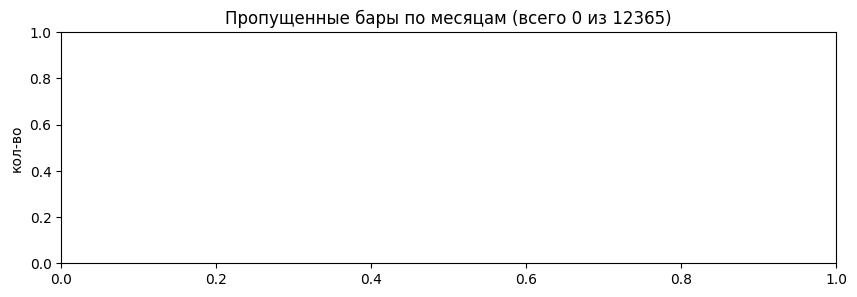

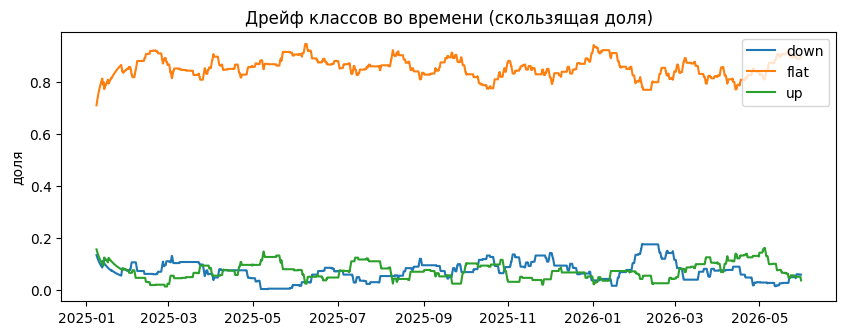

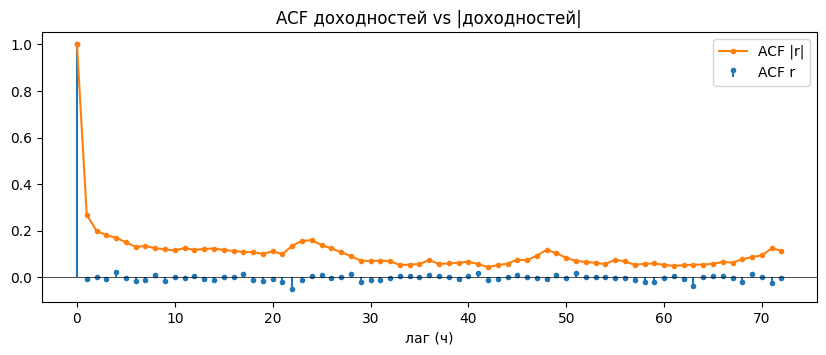

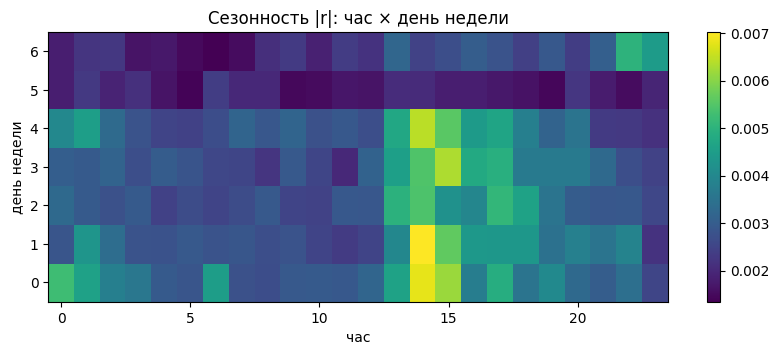

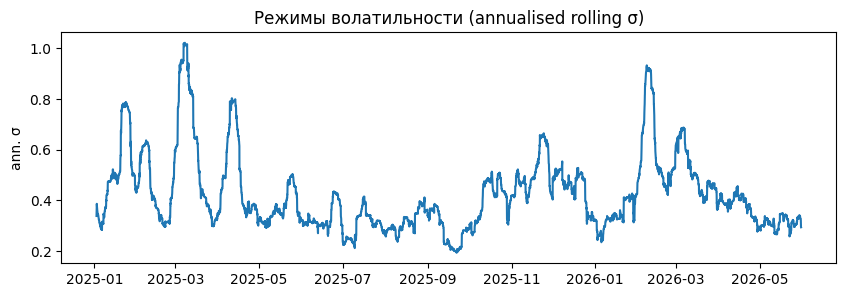

In [4]:
from statsmodels.tsa.stattools import adfuller, kpss
r = np.log(ohlc["BTC_Close"]).diff().dropna()

_, n_missing = plotting.plot_missing_bars(ohlc.index)
print("пропущено баров:", n_missing)

adf_p = adfuller(r.values, autolag="AIC")[1]
with warnings.catch_warnings():
    warnings.simplefilter("ignore"); kpss_p = kpss(r.values, regression="c", nlags="auto")[1]
print(f"ADF p={adf_p:.3g} (стационарность доходностей)  |  KPSS p={kpss_p:.3g}")

plotting.plot_class_drift(pd.Series(y3.values, index=ohlc.index))
plotting.plot_acf_returns(r)
plotting.plot_seasonality(r)
plotting.plot_vol_regime(r)
print("ACF |r| >> ACF r => volatility clustering; доходности ~ белый шум по знаку.")

## §3. Фичи

Трейлинговые, без утечек: лаги лог-доходностей, rolling-волатильность и отношения, нормированные индикаторы (MACD-гистограмма/close, ATR/close, OBV-изменение z-score), лог-объём, MA-отношения, календарь sin/cos. Экзогенка (крипто-натив: funding/basis/orderflow/on-chain/F&G) лагирована у источника. Warmup длинных окон отброшен.

In [5]:
print("число фич:", X.shape[1])
nan_share = X.isna().mean().sort_values(ascending=False)
print("\nТоп по доле NaN (экзогенная эпоха до perp/он-чейна — деревья принимают NaN нативно):")
print(nan_share.head(8).round(3).to_string())
print("\nГруппы фич:", [c for c in X.columns][:20], "...")

число фич: 56

Топ по доле NaN (экзогенная эпоха до perp/он-чейна — деревья принимают NaN нативно):
ret         0.0
ret_lag1    0.0
vol720      0.0
perp_era    0.0
fng_era     0.0
hour_sin    0.0
hour_cos    0.0
dow_sin     0.0

Группы фич: ['ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag6', 'ret_lag12', 'ret_lag24', 'ret_lag48', 'ret_lag72', 'ret_lag168', 'vol24', 'vol72', 'vol168', 'vol_ratio_24_168', 'vol_ratio_24_72', 'rsi', 'macd_hist', 'atr_close', 'obv_chg_z', 'log_volume'] ...


## §4. Метка

Распределение классов для выбранного `TARGET_TYPE`. Порог матчится с правилом выхода (point-to-point ±2% ↔ держать 24ч; barrier ±2% ↔ triple-barrier). Смена типа — мгновенная (метка не кэшируется).

In [6]:
vc = pd.Series(y3).value_counts().reindex([-1,0,1]).rename({-1:"down(-1)",0:"flat(0)",1:"up(+1)"})
print(f"TARGET_TYPE={TARGET_TYPE}")
print((vc / len(y3)).round(3).to_string())
# демонстрация: переключение target_type мгновенно (метка строится на лету)
for tt in ["pointwise","vol_scaled","triple_barrier"]:
    _, yy, *_ = data_io.build_dataset(target_type=tt, k=(VOL_K if tt=="vol_scaled" else None), frame=frame)
    print(f"  {tt:14s}: {dict(zip(*np.unique(yy, return_counts=True)))}")

02:37:34 INFO src.data_io | dataset[pointwise]: 12384 rows, 56 features, classes={-1: 1903, 0: 8718, 1: 1763}


02:37:34 INFO src.data_io | dataset[vol_scaled, k=1.5]: 12365 rows, 56 features, classes={-1: 891, 0: 10604, 1: 870}


02:37:34 INFO src.data_io | dataset[triple_barrier]: 12384 rows, 56 features, classes={-1: 3721, 0: 5283, 1: 3380}


TARGET_TYPE=vol_scaled
down(-1)    0.072
flat(0)     0.858
up(+1)      0.070
  pointwise     : {-1: 1903, 0: 8718, 1: 1763}
  vol_scaled    : {-1: 891, 0: 10604, 1: 870}
  triple_barrier: {-1: 3721, 0: 5283, 1: 3380}


## §5. Валидация

Хронологический train/val/test (тест открывается один раз в §8). Основной метод отбора/тюнинга — **purged + embargoed walk-forward** (forward-chaining; train всегда строго раньше test; purge=HORIZON + embargo). Это НЕ обычный k-fold.

In [7]:
n = len(X)
test_start = int((config.SPLIT[0] + config.SPLIT[1]) * n)   # 85% -> dev, 15% -> test
X_dev, y_dev, fwd_dev = X.iloc[:test_start], y3.iloc[:test_start], fwd.iloc[:test_start]
X_test, y_test, fwd_test = X.iloc[test_start:], y3.iloc[test_start:], fwd.iloc[test_start:]
ohlc_dev, ohlc_test = ohlc.iloc[:test_start], ohlc.iloc[test_start:]

dev_splits = validation.purged_walk_forward_splits(
    len(X_dev), n_splits=config.wf_splits(), purge=config.PURGE, embargo=config.EMBARGO,
    window_mode=config.WINDOW_MODE, train_window=config.TRAIN_WINDOW)
print(f"dev={len(X_dev)}  test={len(X_test)}  | WF folds={len(dev_splits)}")
for i,(tr,te) in enumerate(dev_splits):
    assert tr.max() + config.HORIZON < te.min()             # R1 STRICT (V7): метка train не заходит в test
    print(f"  fold {i}: train[{tr.min()}:{tr.max()}]  test[{te.min()}:{te.max()}]")
print("R1 purge OK (строгий): ни одна train-метка не пересекает тест.")

dev=10510  test=1855  | WF folds=3
  fold 0: train[0:5206]  test[5255:7005]
  fold 1: train[0:6957]  test[7006:8756]
  fold 2: train[0:8708]  test[8757:10507]
R1 purge OK (строгий): ни одна train-метка не пересекает тест.


## §6. Сравнение постановок A / B / C (главная часть)

Каждая постановка тюнится Optuna (TPE+MedianPruner) на purged walk-forward по **MCC**, затем собираем OOF-предсказания и считаем полный `evaluate()`. Сравниваем **распределения по фолдам** (boxplot), а не одиночные числа; накладываем precision-at-coverage; Diebold–Mariano между постановками.

In [8]:
SETUP_KEYS = ["A","B","C1","C2"]
results, studies = {}, {}
past_dev = ohlc_dev["BTC_Close"].pct_change(config.HORIZON)
_t6 = time.time()
for key in SETUP_KEYS:
    _tk = time.time()
    if key in ("A","B","C1"):
        best, st = optimize.tune_setup(key, X_dev, y_dev, fwd_dev, splits=dev_splits,
                                       artifact_path=str(config.ROOT/"reports"/f"study_{TAG}_{key}.json"))
        studies[key] = st
    else:
        best = results["C1"]["params"]                       # c2 берёт параметры c1 (две вариации каскада)
    oof = optimize.walk_forward_oof(key, X_dev, y_dev, fwd_dev, dev_splits, params=best)
    pos = oof["pos"]
    ev = metrics.evaluate(oof["y_true"], oof["y_pred"], oof["proba"], oof["fwd"], oof["signal"],
        n_trials=1, past_return=past_dev.to_numpy()[pos], ohlc=ohlc_dev.iloc[pos],
        position=pd.Series(oof["y_pred"], index=ohlc_dev.index[pos]),
        bt_cfg=config.BACKTEST_CFG, ic_periods=oof["fold"], bets_per_year=config.BETS_PER_YEAR)
    results[key] = {"params": best, "oof": oof, "ev": ev}
    print(f"  {key}: {time.time()-_tk:.1f}s")
TIMINGS["s6_abc_tune_s"] = round(time.time() - _t6, 1)

rows = []
for k in SETUP_KEYS:
    cl, ev = results[k]["ev"]["classification"], results[k]["ev"]
    econ = ev.get("economics", {}).get("strategy", {})
    rows.append({"setup": k, "MCC": cl["mcc"], "macro_F1": cl["macro"]["f1"],
                 "recall+1": cl["recall_up"], "recall-1": cl["recall_down"],
                 "IC": ev["ic"]["rank_ic"], "IC_IR": ev["ic"].get("ic_ir", np.nan),
                 "Sharpe": econ.get("sharpe", np.nan), "ΔMCC_maj": ev["baseline_delta_mcc"].get("majority", np.nan)})
table = pd.DataFrame(rows).set_index("setup").round(3)
table

  A: 14.5s


  B: 14.8s


  C1: 9.5s


  C2: 2.6s


,MCC,macro_F1,recall+1,recall-1,IC,IC_IR,Sharpe,ΔMCC_maj
setup,,,,,,,,
A,0.062,0.344,0.350,0.129,0.001,-0.162,-0.172,0.062
B,0.019,0.339,0.045,0.032,0.006,0.025,12.310,0.019
C1,0.121,0.402,0.190,0.159,-0.017,-0.456,1.543,0.121
C2,0.100,0.378,0.166,0.086,-0.082,-0.594,1.332,0.100


Лучшая постановка по dev-MCC: C1



DM-статистика (строка vs столбец):


,A,B,C1,C2
A,NaN,-0.60,1.38,-1.37
B,0.60,NaN,1.44,-0.79
C1,-1.38,-1.44,NaN,-1.87
C2,1.37,0.79,1.87,NaN


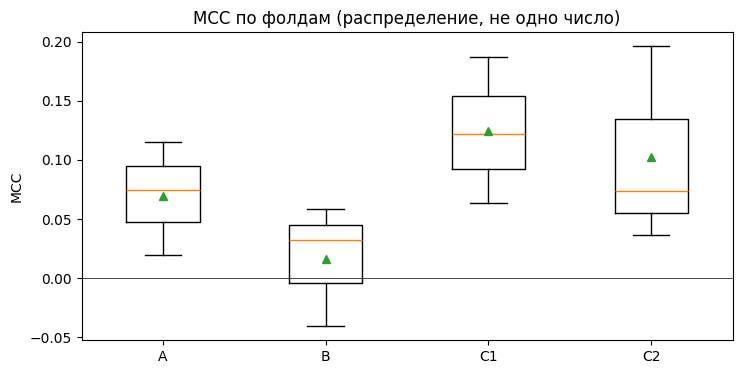

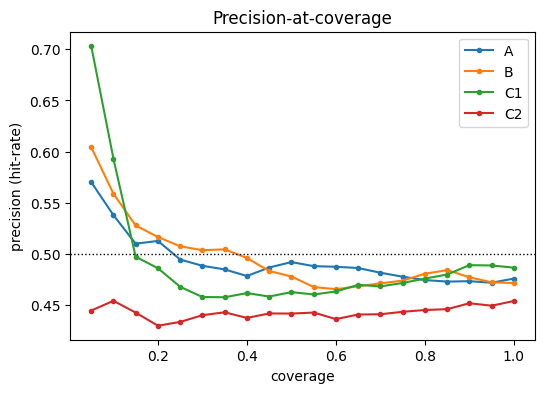

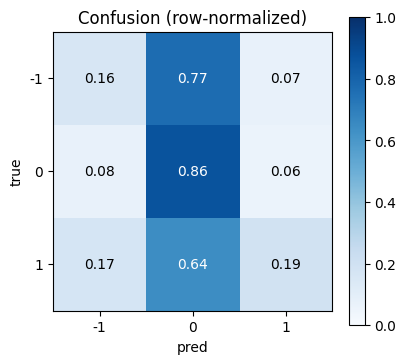

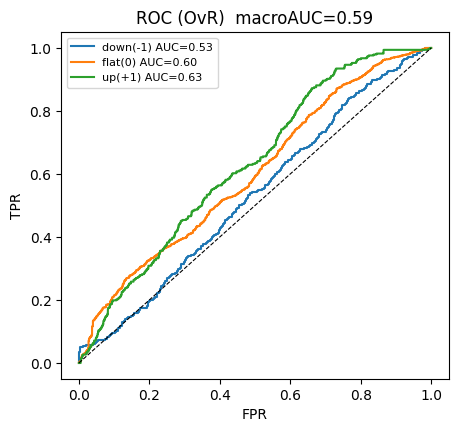

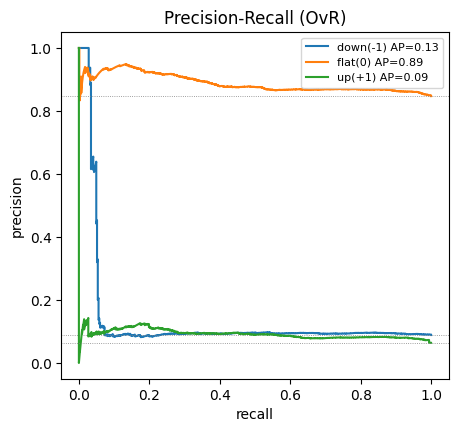

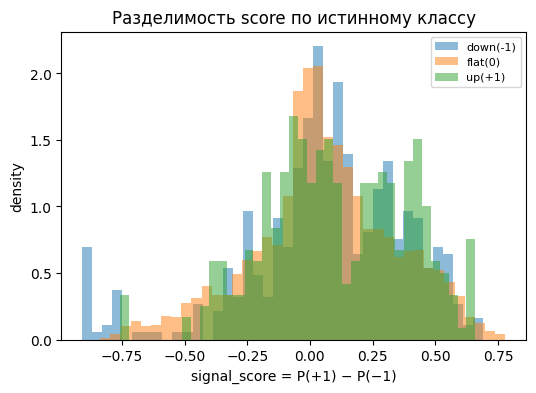

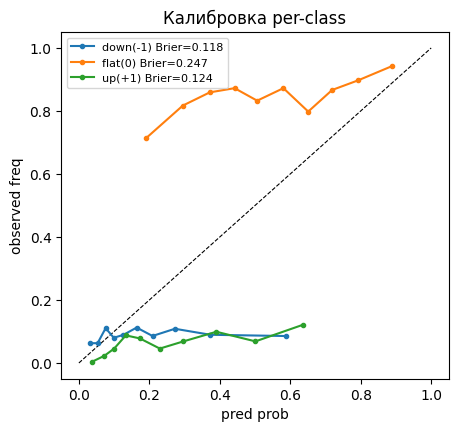

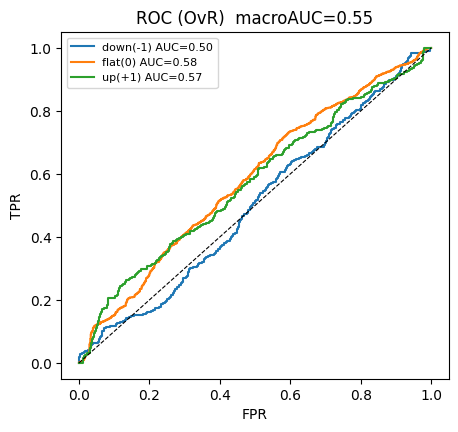

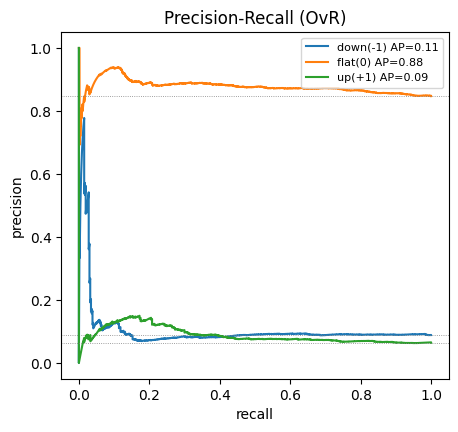

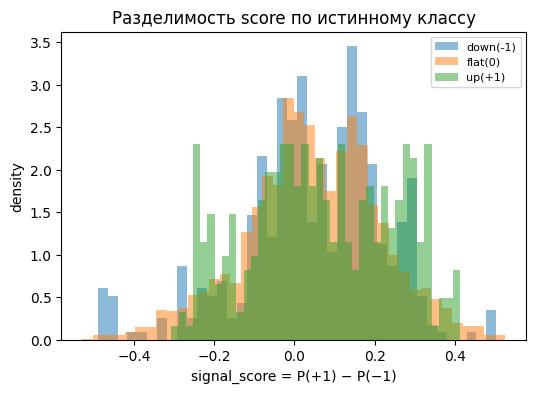

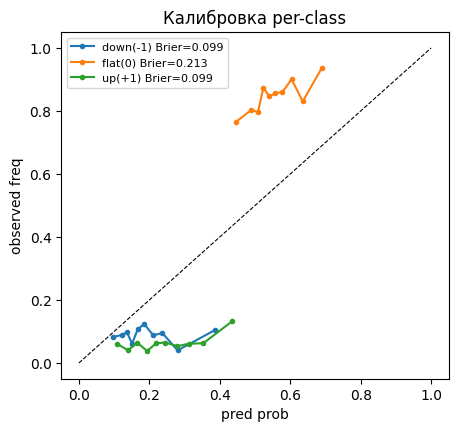

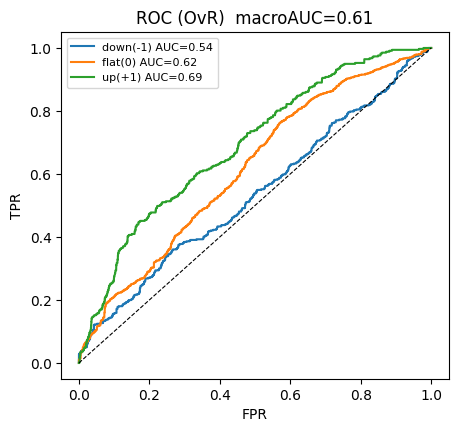

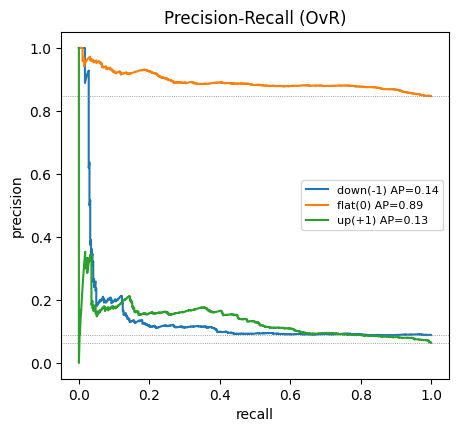

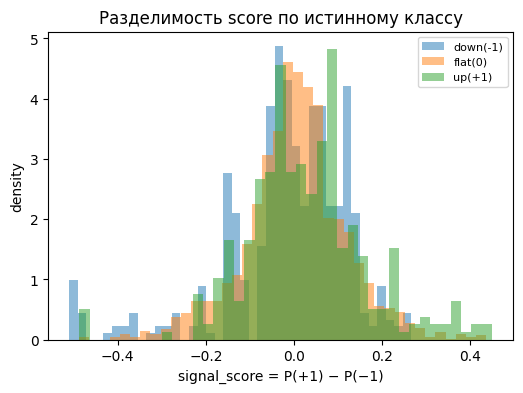

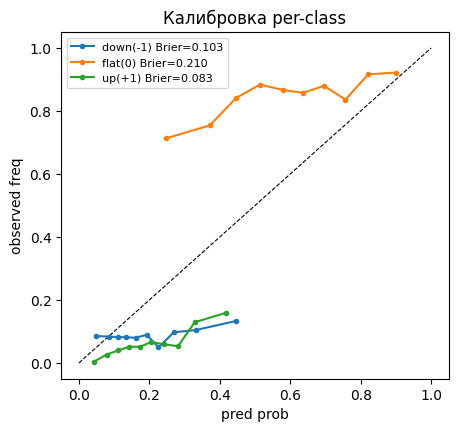

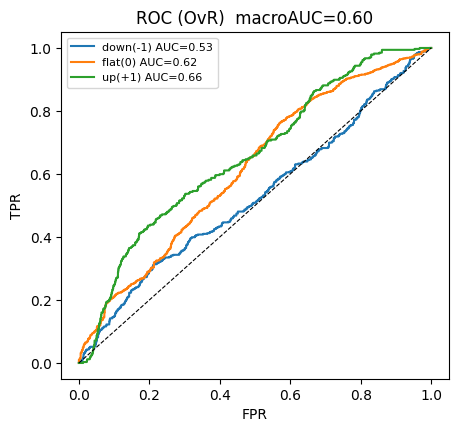

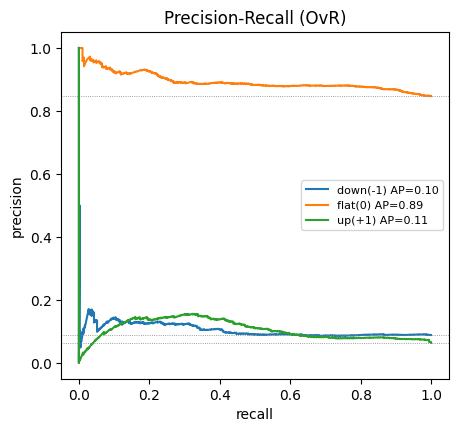

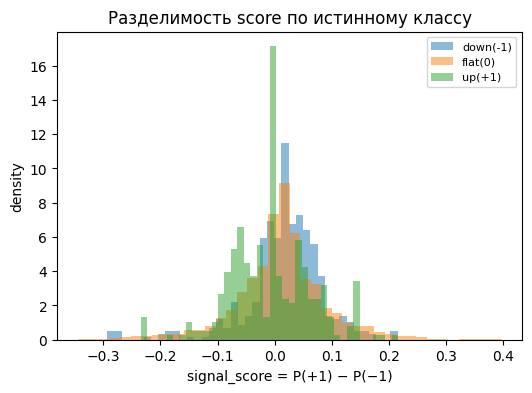

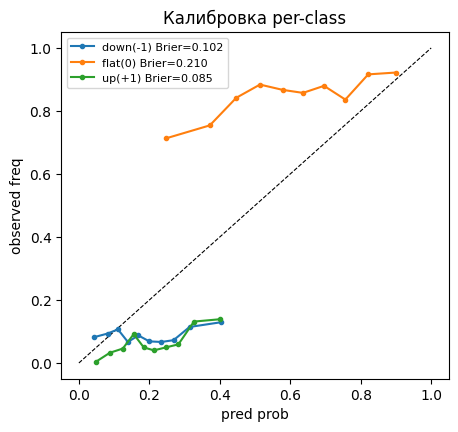

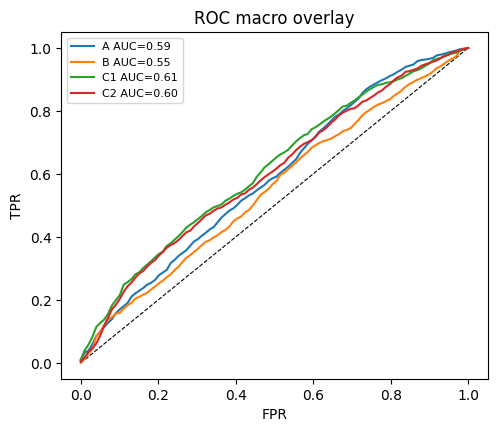

In [9]:
# распределения по фолдам + precision-at-coverage + confusion лучшей постановки
plotting.plot_fold_boxplot({k: results[k]["oof"]["per_fold_mcc"] for k in SETUP_KEYS}, metric="MCC")
plotting.plot_precision_at_coverage({k: results[k]["ev"]["decision"]["pac_both"] for k in SETUP_KEYS})
best_key = table["MCC"].idxmax()
plotting.plot_confusion(results[best_key]["ev"]["classification"]["confusion_norm"], name=f"confusion_{best_key}")
print("Лучшая постановка по dev-MCC:", best_key)

# дешёвые quality-плоты для КАЖДОЙ постановки (W7) -> pictures/<TAG>/
for k in SETUP_KEYS:
    o = results[k]["oof"]
    plotting.plot_roc_ovr(o["y_true"], o["proba"], name=f"roc_{k}")
    plotting.plot_pr_curves(o["y_true"], o["proba"], name=f"pr_{k}")
    plotting.plot_score_separation(o["y_true"], o["signal"], name=f"score_sep_{k}")
    plotting.plot_calibration_per_class(o["y_true"], o["proba"], name=f"calib_{k}")
plotting.plot_roc_overlay({k: (results[k]["oof"]["y_true"], results[k]["oof"]["proba"]) for k in SETUP_KEYS})

# Diebold-Mariano между постановками (loss = -(sign(signal)*fwd); отрицат. stat => строка точнее столбца)
import itertools
dm = pd.DataFrame(index=SETUP_KEYS, columns=SETUP_KEYS, dtype=float)
for a,b in itertools.product(SETUP_KEYS, SETUP_KEYS):
    if a==b: dm.loc[a,b]=np.nan; continue
    la = -(np.sign(results[a]["oof"]["signal"])*results[a]["oof"]["fwd"])
    lb = -(np.sign(results[b]["oof"]["signal"])*results[b]["oof"]["fwd"])
    dm.loc[a,b] = metrics.diebold_mariano(la, lb, h=config.HORIZON, loss="identity")[0]
print("\nDM-статистика (строка vs столбец):");
dm.round(2)

## §7. Диагностика переобучения + авто-тесты утечки

train/val MCC, permutation importance (не MDI), и три авто-теста утечки: сильный позитивный контроль (метка как фича → ~идеал), shuffle таргета → падение до baseline, сдвиг фич на горизонт вперёд → рост (на 24ч-метке однобаровый peek не информативен — сдвигаем на HORIZON).

C1: MCC train=+0.711  WF-OOF(dev)=+0.121  (зазор = переобучение)


Permutation importance построена (top -> pictures/).


Дрейф-триггеры (фолды PSI>0.2): [0, 1, 2]


SHAP: пропущен (shap не установлен)
Window ablation выключена (RUN_WINDOW_ABLATION=False).


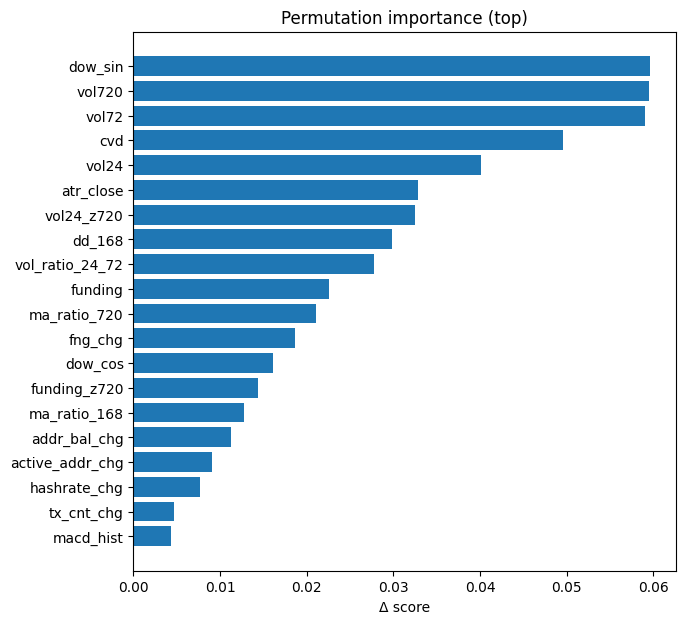

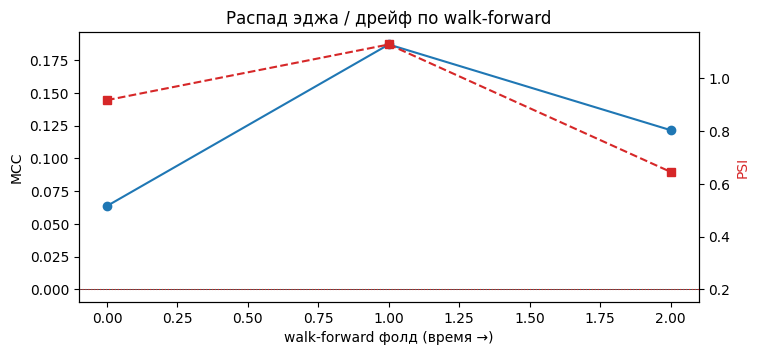

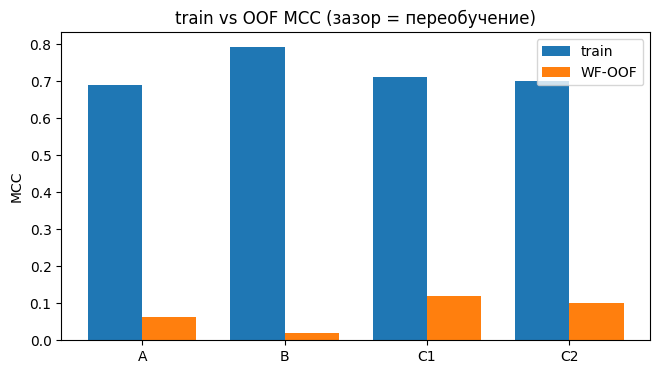

In [10]:
from sklearn.metrics import matthews_corrcoef
# train vs WF-OOF (dev) для лучшей постановки
setup = models.SETUPS[best_key](params=results[best_key]["params"])
setup.fit(X_dev, y_dev.values, y_ret=fwd_dev.values)
mcc_train = matthews_corrcoef(y_dev, setup.predict(X_dev))
mcc_oof   = matthews_corrcoef(results[best_key]["oof"]["y_true"], results[best_key]["oof"]["y_pred"])
print(f"{best_key}: MCC train={mcc_train:+.3f}  WF-OOF(dev)={mcc_oof:+.3f}  (зазор = переобучение)")

# permutation importance (на последнем фолде dev; падение MCC при перемешивании фичи)
tr,te = dev_splits[-1]
s = models.SETUPS[best_key](params=results[best_key]["params"]); s.fit(X_dev.iloc[tr], y_dev.values[tr], y_ret=fwd_dev.values[tr])
base = matthews_corrcoef(y_dev.values[te], s.predict(X_dev.iloc[te]))
rng = np.random.default_rng(config.SEED); imp = {}
for c in X_dev.columns:
    Xp = X_dev.iloc[te].copy(); Xp[c] = rng.permutation(Xp[c].values)
    imp[c] = base - matthews_corrcoef(y_dev.values[te], s.predict(Xp))
plotting.plot_permutation_importance(list(imp.keys()), list(imp.values()), name=f"perm_importance_{best_key}")
print("Permutation importance построена (top -> pictures/).")

# edge-decay + дрейф по walk-forward (W5)
psi = validation.fold_drift(X_dev.to_numpy(), dev_splits)
plotting.plot_edge_decay(results[best_key]["oof"]["per_fold_mcc"], psi, name=f"edge_decay_{best_key}")
print("Дрейф-триггеры (фолды PSI>0.2):", validation.drift_triggered_schedule(psi))

# train-vs-OOF gap по ВСЕМ постановкам (W7) — переобучение
gaps = {}
for k in SETUP_KEYS:
    s2 = models.SETUPS[k](params=results[k]["params"]); s2.fit(X_dev, y_dev.values, y_ret=fwd_dev.values)
    gaps[k] = (matthews_corrcoef(y_dev, s2.predict(X_dev)),
               matthews_corrcoef(results[k]["oof"]["y_true"], results[k]["oof"]["y_pred"]))
plotting.plot_train_oof_gap(gaps, name="train_oof_gap")

# SHAP победителя (TreeExplainer; тихо пропускается, если shap не установлен) — W7
try:
    bm = models.SETUPS[best_key](params=results[best_key]["params"]); bm.fit(X_dev, y_dev.values, y_ret=fwd_dev.values)
    base_model = getattr(bm, "model_", getattr(bm, "gate_", None))
    if base_model is not None and not isinstance(base_model, models._ConstantProba):
        samp = X_dev.sample(min(2000, len(X_dev)), random_state=config.SEED).astype("float32")
        r = plotting.plot_shap_summary(base_model, samp, name=f"shap_{best_key}")
        print("SHAP:", "построен" if r else "пропущен (shap не установлен)")
except Exception as e:
    print("SHAP пропущен:", e)

# окно-аблация (W5): expanding vs rolling 2г/4г — устойчивость по режимам
if RUN_WINDOW_ABLATION:
    abl = {}
    for wm, tw in [("expanding", None), ("rolling", 24*365*2), ("rolling", 24*365*4)]:
        if tw is not None and tw >= len(X_dev):
            continue
        sp = validation.purged_walk_forward_splits(len(X_dev), n_splits=config.wf_splits(),
             purge=config.PURGE, embargo=config.EMBARGO, window_mode=wm, train_window=tw)
        o = optimize.walk_forward_oof(best_key, X_dev, y_dev, fwd_dev, sp, params=results[best_key]["params"])
        abl[f"{wm}" + ("" if tw is None else f"/{tw//(24*365)}y")] = o["per_fold_mcc"]
    if abl:
        plotting.plot_fold_boxplot(abl, metric="MCC", name="window_ablation")
        print("Window ablation MCC:", {k: round(float(np.nanmean(v)), 3) for k, v in abl.items()})
else:
    print("Window ablation выключена (RUN_WINDOW_ABLATION=False).")

In [11]:
# ── авто-тесты утечки ──
# (a) сильный позитивный контроль (data-agnostic): МЕТКА как фича -> ~идеал для ЛЮБОГО
#     типа метки. (fwd_ret был бы оракулом только для pointwise: у vol_scaled порог
#     k·σ_t per-row, у triple_barrier метка зависит от барьера — поэтому инжектим саму метку.)
Xl = X_dev.copy(); Xl["LEAK_label"] = y_dev.values.astype(float)
oof_l = optimize.walk_forward_oof("A", Xl, y_dev, fwd_dev, dev_splits)
mcc_leak = matthews_corrcoef(oof_l["y_true"], oof_l["y_pred"])
# (b) shuffle y -> baseline
ys = pd.Series(np.random.default_rng(config.SEED).permutation(y_dev.values), index=y_dev.index)
oof_s = optimize.walk_forward_oof("A", X_dev, ys, fwd_dev, dev_splits)
mcc_shuf = matthews_corrcoef(oof_s["y_true"], oof_s["y_pred"])
# (c) сдвиг фич на HORIZON вперёд -> рост
Xp = X_dev.shift(-config.HORIZON); v = Xp.notna().all(axis=1)
oof_p = optimize.walk_forward_oof("A", Xp[v].reset_index(drop=True), y_dev[v].reset_index(drop=True),
                                  fwd_dev[v].reset_index(drop=True), optimize.make_splits(int(v.sum())))
mcc_peek = matthews_corrcoef(oof_p["y_true"], oof_p["y_pred"])
print(f"(a) метка-как-фича MCC={mcc_leak:.3f}  (должно ~1)")
print(f"(b) shuffle-y     MCC={mcc_shuf:+.3f}  (должно ~0)")
print(f"(c) peek(+{config.HORIZON}ч) MCC={mcc_peek:.3f}  vs honest {mcc_oof:+.3f}  (должно вырасти)")
assert mcc_leak > 0.9 and abs(mcc_shuf) < 0.1, "leakage tripwire не сработал!"
print("\nАвто-тесты утечки пройдены.")

(a) метка-как-фича MCC=1.000  (должно ~1)
(b) shuffle-y     MCC=-0.006  (должно ~0)
(c) peek(+24ч) MCC=0.664  vs honest +0.121  (должно вырасти)

Авто-тесты утечки пройдены.


## §8. Финальный тест (один раз) + экономика

Лучшая постановка обучается на dev и применяется к отложенному тесту ОДИН раз. Экономика: бэктест со входом по `open[t+1]`, держание горизонта, издержки bps, усреднение по фазам входа; бенчмарк buy-and-hold + vol-targeted. DSR с `n_trials`, учитывающим ВЕСЬ грид (постановки × target_types × Optuna-trials, R12).

=== ТЕСТ (C1) ===
MCC=+0.079  macroF1=0.351  bal_acc=0.367
IC=+0.014  ROC-AUC(OvR)=0.619  ECE=0.123
Strategy Sharpe=-2.77  B&H Sharpe=+0.59  ΔSharpe=-3.36
PSR=0.187  DSR=0.000  (n_trials_grid=90)
DM vs naive: stat=-1.03 p=0.305


PosixPath('/Users/tigran/python_projects_epta/personal_projects/diploma/pictures/vol_scaled_k1.5/confusion_test_C1.png')

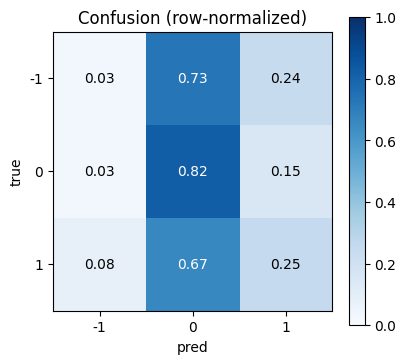

In [12]:
final = models.SETUPS[best_key](params=results[best_key]["params"])
final.fit(X_dev, y_dev.values, y_ret=fwd_dev.values)
proba_t = final.predict_proba3(X_test); pred_t = np.asarray(models.CLASSES)[proba_t.argmax(1)]
sig_t = proba_t[:,2]-proba_t[:,0]
past_test = ohlc_test["BTC_Close"].pct_change(config.HORIZON)

# n_trials для DSR = весь пред-зарегистрированный грид (R12)
trials_per_setup = int(np.mean([len(s.trials) for s in studies.values()])) if studies else config.n_trials()
n_trials_grid = trials_per_setup * 3 * len(config.TARGET_TYPES)   # 3 постановки × 3 target_types
# распределение Sharpe по постановкам/фолдам как выборка испытаний для DSR
trial_sharpes = [results[k]["ev"].get("economics",{}).get("strategy",{}).get("sharpe", np.nan) for k in SETUP_KEYS]
trial_sharpes = [s for s in trial_sharpes if np.isfinite(s)]

ev_test = metrics.evaluate(y_test.values, pred_t, proba_t, fwd_test.values, sig_t,
    n_trials=n_trials_grid, past_return=past_test.values, ohlc=ohlc_test,
    position=pd.Series(pred_t, index=ohlc_test.index), bt_cfg=config.BACKTEST_CFG,
    ic_periods=None, trial_sharpes=trial_sharpes, bets_per_year=config.BETS_PER_YEAR)

cl = ev_test["classification"]; econ = ev_test["economics"]
print(f"=== ТЕСТ ({best_key}) ===")
print(f"MCC={cl['mcc']:+.3f}  macroF1={cl['macro']['f1']:.3f}  bal_acc={cl['balanced_accuracy']:.3f}")
print(f"IC={ev_test['ic']['rank_ic']:+.3f}  ROC-AUC(OvR)={ev_test['proba']['roc_auc_ovr']:.3f}  ECE={ev_test['proba']['ece']:.3f}")
print(f"Strategy Sharpe={econ['strategy'].get('sharpe',np.nan):+.2f}  B&H Sharpe={econ['buy_hold'].get('sharpe',np.nan):+.2f}  ΔSharpe={econ['delta_vs_bh'].get('d_sharpe',np.nan):+.2f}")
print(f"PSR={ev_test['exotic'].get('psr',np.nan):.3f}  DSR={ev_test['exotic'].get('dsr',np.nan):.3f}  (n_trials_grid={n_trials_grid})")
print(f"DM vs naive: stat={ev_test['exotic'].get('dm_vs_naive',{}).get('stat',np.nan):+.2f} p={ev_test['exotic'].get('dm_vs_naive',{}).get('p_value',np.nan):.3f}")
plotting.plot_confusion(cl["confusion_norm"], name=f"confusion_test_{best_key}")

Сделок (фаза 0): 14 | per-phase mean cumret: -0.0462
 fee_bps  sharpe  cumret  n_trades
     0.0   -2.10   -0.04     15.33
     5.0   -2.58   -0.04     15.33
     7.0   -2.77   -0.05     15.33
    10.0   -3.06   -0.05     15.33
    15.0   -3.54   -0.06     15.33
    20.0   -4.03   -0.06     15.33
    30.0   -4.99   -0.08     15.33
    40.0   -5.96   -0.09     15.33
MDD duration=11.291666666666666 сделок | CAGR=-0.104


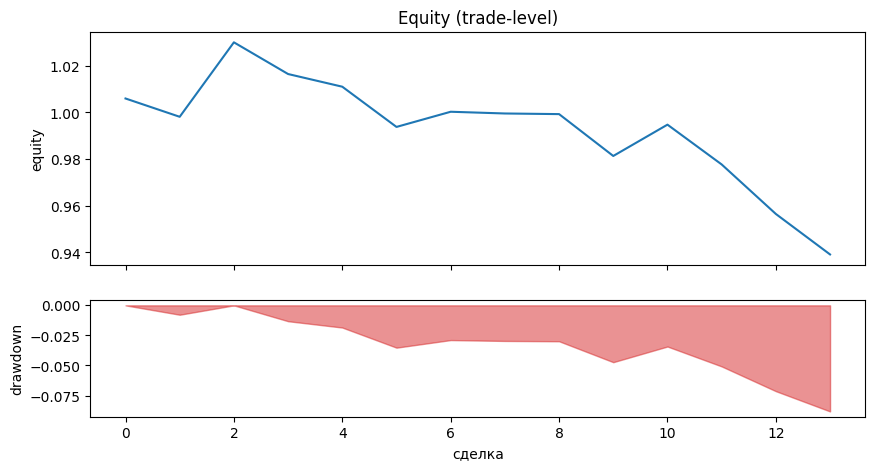

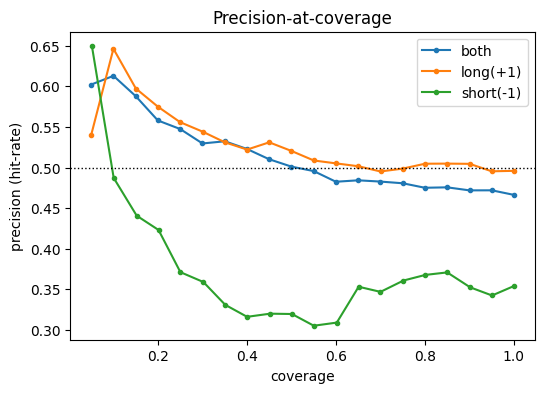

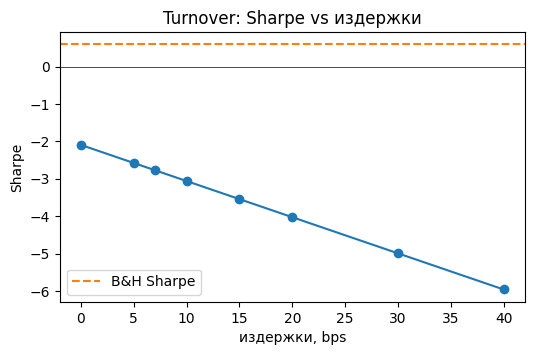

In [13]:
# equity + drawdown на тестовых сделках + precision-at-coverage
sim = backtest.simulate_horizon_strategy(pd.Series(pred_t, index=ohlc_test.index), ohlc_test,
                                         config.BACKTEST_CFG, bets_per_year=config.BETS_PER_YEAR)
plotting.plot_equity_drawdown(sim["trade_returns"], name=f"equity_test_{best_key}")
plotting.plot_precision_at_coverage({
    "both": ev_test["decision"]["pac_both"], "long(+1)": ev_test["decision"]["pac_long"],
    "short(-1)": ev_test["decision"]["pac_short"]}, name="precision_at_coverage_test")
print("Сделок (фаза 0):", len(sim["trade_returns"]), "| per-phase mean cumret:", round(sim["mean"].get("cumret",np.nan),4))

# turnover: Sharpe vs издержки (W6) + breakeven относительно B&H
import matplotlib.pyplot as plt
sweep = backtest.cost_sharpe_sweep(pd.Series(pred_t, index=ohlc_test.index), ohlc_test,
                                   config.BACKTEST_CFG, bets_per_year=config.BETS_PER_YEAR)
figc, axc = plt.subplots(figsize=(6,3.5)); axc.plot(sweep["fee_bps"], sweep["sharpe"], "o-")
axc.axhline(0, color="k", lw=0.5)
axc.axhline(econ["buy_hold"].get("sharpe", np.nan), color="C1", ls="--", label="B&H Sharpe")
axc.set_xlabel("издержки, bps"); axc.set_ylabel("Sharpe"); axc.set_title("Turnover: Sharpe vs издержки"); axc.legend()
plotting.save_fig(figc, f"cost_sweep_{best_key}")
print(sweep.round(2).to_string(index=False))
print(f"MDD duration={econ['strategy'].get('mdd_duration','?')} сделок | CAGR={econ['strategy'].get('cagr',np.nan):+.3f}")

## §8b. Робастность: CPCV (несколько путей) + PBO

Combinatorial Purged CV даёт МНОЖЕСТВО backtest-путей (ниже дисперсия оценки) и служит основой **PBO (CSCV)** — вероятности переобучения бэктеста. Это вторичная, не deploy-честная оценка (CPCV обучает и на пост-тестовых данных), поэтому смотрим её ВМЕСТЕ с walk-forward. PBO→1 = лидер бэктеста, скорее всего, переобучен.

CPCV: 15 путей (N=6,k=2). Медианный MCC по путям:
A     0.056
B    -0.007
C1    0.082
C2    0.062



PBO (CSCV по 15 путям × 4 постановок): 0.14


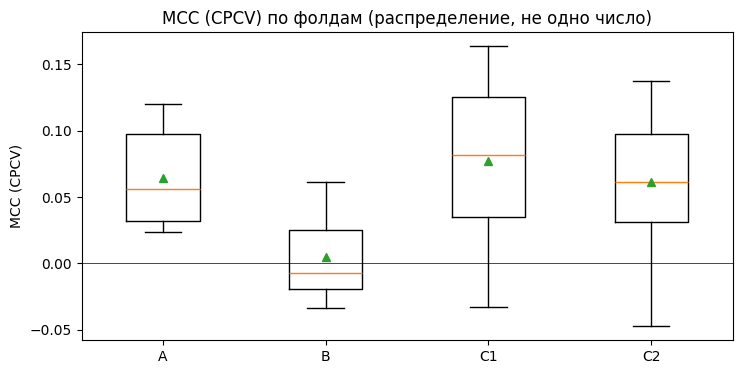

In [14]:
if RUN_CPCV:
    from sklearn.metrics import matthews_corrcoef
    st = config.settings()
    paths = list(validation.cpcv_splits(len(X_dev), N=st["cpcv_N"], k=st["cpcv_k"], horizon=config.HORIZON))
    perf = []                       # матрица (пути × постановки) для PBO
    for tr, te in paths:
        row = []
        for k in SETUP_KEYS:
            s = models.SETUPS[k](params=results[k]["params"]); s.fit(X_dev.iloc[tr], y_dev.values[tr], y_ret=fwd_dev.values[tr])
            row.append(matthews_corrcoef(y_dev.values[te], s.predict(X_dev.iloc[te])) if np.unique(y_dev.values[te]).size > 1 else np.nan)
        perf.append(row)
    perf = np.array(perf)
    cpcv_tab = pd.DataFrame(perf, columns=SETUP_KEYS)
    print(f"CPCV: {len(paths)} путей (N={st['cpcv_N']},k={st['cpcv_k']}). Медианный MCC по путям:")
    print(cpcv_tab.median().round(3).to_string())
    plotting.plot_fold_boxplot({k: cpcv_tab[k].values for k in SETUP_KEYS}, metric="MCC (CPCV)", name="cpcv_boxplot")
    pbo = metrics.prob_backtest_overfitting(perf, n_splits=min(16, perf.shape[0]))
    print(f"\nPBO (CSCV по {perf.shape[0]} путям × {perf.shape[1]} постановок):",
          round(pbo, 3) if pbo == pbo else "n/a (мало путей — нужен FULL)")
else:
    print("CPCV выключен (RUN_CPCV=False).")

## §9. (опц.) Ablation: Yahoo кросс-активы

Yahoo 1h ограничен ~729 днями, поэтому кросс-активы — НЕ в дефолтной модели (схлопнули бы окно). Здесь — отдельная проверка их вклада на коротком окне. Включается флагом (по умолчанию выкл — сетевой и медленный).

In [15]:
if RUN_YAHOO_ABLATION:
    frame_y = features.attach_yahoo_crossassets(frame.copy())
    Xy, yy, fwy, oy, _ = data_io.build_dataset(target_type=TARGET_TYPE, frame=frame_y)
    sp = optimize.make_splits(int(0.85*len(Xy)))
    oof_y = optimize.walk_forward_oof("A", Xy.iloc[:int(0.85*len(Xy))], yy.iloc[:int(0.85*len(Xy))],
                                      fwy.iloc[:int(0.85*len(Xy))], sp)
    from sklearn.metrics import matthews_corrcoef
    print("A с Yahoo-кросс-активами MCC(OOF) =", round(matthews_corrcoef(oof_y["y_true"], oof_y["y_pred"]),3),
          "vs без =", round(mcc_oof,3))
else:
    print("Ablation выключена (RUN_YAHOO_ABLATION=False).")

Ablation выключена (RUN_YAHOO_ABLATION=False).


## §10. Сравнение обучателей (на постановке A — 3-class softmax)

Постановки A/B/C сравниваются на ОДНОМ обучателе (LightGBM). Здесь обратный срез: фиксируем формулировку A (multiclass-голова) и сравниваем **LightGBM / XGBoost / CatBoost / нейросети (MLP, GRU, TCN)** на ТЕХ ЖЕ walk-forward фолдах — изолируем эффект обучателя. Нейросети гонятся в **отдельном субпроцессе** (`run_nn_comparison.py`): torch и LightGBM не в одном процессе (macOS libomp-segfault); на P100 — CUDA, локально — CPU. Авто-тесты утечки проходят и для NN. Запускается ОДИН раз — на основном эксперименте (pointwise).

In [16]:
if RUN_LEARNER_COMPARISON:
    from sklearn.metrics import matthews_corrcoef
    from lightgbm import LGBMClassifier
    from xgboost import XGBClassifier
    from catboost import CatBoostClassifier
    NE = min(400, config.n_estimators_cap())
    learners = {
        "LightGBM": LGBMClassifier(**{**config.LGBM_DETERMINISTIC, "objective":"multiclass",
                                      "num_class":3, "n_estimators":NE, "learning_rate":0.05, "n_jobs":1}),
        "XGBoost":  XGBClassifier(objective="multi:softprob", num_class=3, n_estimators=NE,
                                  learning_rate=0.05, max_depth=6, tree_method="hist",
                                  random_state=config.SEED, n_jobs=1, verbosity=0),
        "CatBoost": CatBoostClassifier(loss_function="MultiClass", n_estimators=NE, learning_rate=0.05,
                                       random_seed=config.SEED, thread_count=1, verbose=0, allow_writing_files=False),
    }
    rows, learner_oof = [], {}
    for lname, clf in learners.items():
        trues, preds, probas = [], [], []
        for tr, te in dev_splits:
            clf.fit(X_dev.iloc[tr], (y_dev.values[tr] + 1))      # {-1,0,1}->{0,1,2}
            pr = np.asarray(clf.predict_proba(X_dev.iloc[te]))
            probas.append(pr); preds.append(pr.argmax(1) - 1); trues.append(y_dev.values[te])
        yt, yp, pp = np.concatenate(trues), np.concatenate(preds), np.concatenate(probas)
        learner_oof[lname] = (yt, pp)
        rows.append({"learner": lname, "WF_OOF_MCC": matthews_corrcoef(yt, yp)})
        plotting.plot_roc_ovr(yt, pp, name=f"learner_{lname}_roc")     # W7 per-learner
        plotting.plot_pr_curves(yt, pp, name=f"learner_{lname}_pr")
    # ── нейросети: ОТДЕЛЬНЫЙ субпроцесс (torch ⟂ LightGBM); только на pointwise ──
    nn_summary = None
    if RUN_NN and TARGET_TYPE == "pointwise":
        import subprocess, json, hashlib
        def _fp(splits):
            h = hashlib.sha256()
            for tr, te in splits: h.update(np.asarray(tr).tobytes()); h.update(np.asarray(te).tobytes())
            return h.hexdigest()[:16]
        cmd = [sys.executable, str(ROOT / "run_nn_comparison.py"), "--tag", TAG]
        if config.QUICK_MODE: cmd.append("--quick")
        env = dict(os.environ); env["NB_QUICK"] = "1" if config.QUICK_MODE else "0"
        print("NN-субпроцесс:", " ".join(cmd))
        subprocess.run(cmd, env=env, check=True)
        nn_summary = json.loads((ROOT / "reports" / "nn_comparison.json").read_text())
        assert nn_summary["split_fingerprint"] == _fp(dev_splits), "NN-фолды НЕ совпадают с §10 (V5)!"
        for name, d in nn_summary["learners"].items():
            rows.append({"learner": name, "WF_OOF_MCC": d["mcc"]})
        print("NN-фолды идентичны §10 (V5 OK); NN-тесты утечки:", nn_summary.get("leakage", {}).get("pass"))
    elif RUN_NN:
        print("NN пропущены: запускаются только на pointwise.")
    lt = pd.DataFrame(rows).set_index("learner").round(3)
    plotting.plot_roc_overlay(learner_oof, name="learner_roc_overlay")
    print("Сравнение обучателей на постановке A (WF-OOF MCC на dev):"); print(lt.to_string())
    print("\nЧестно: эффективных независимых примеров мало (~3200 на полной истории, ~540 QUICK)")
    print("-> NN склонны переобучаться, GBM обычно лидируют на табличке этого масштаба.")
else:
    print("Сравнение обучателей выключено (RUN_LEARNER_COMPARISON=False).")

Сравнение обучателей выключено (RUN_LEARNER_COMPARISON=False).


## §11. Итоги и полный прогон

- Сравнение **A/B/C** — таблица §6 (распределения по фолдам, не одиночные числа) + DM + precision-at-coverage.
- Утечек нет (§7 авто-тесты), валидация — purged walk-forward (§5), полный модуль метрик (§6/§8).
- Робастность — CPCV+PBO (§8b); обратный срез по обучателям LGBM/XGB/CatBoost (§10); Yahoo-аблация (§9).
- **Полный прогон по максимуму** — одной командой: `.venv/bin/python run_full.py` (QUICK_MODE=False, пересборка полной истории один раз, затем прогон ноутбука на каждом `TARGET_TYPE ∈ {pointwise, triple_barrier, vol_scaled}`, для vol_scaled — каждый `k ∈ {1.0,1.5,2.0}` как отдельный эксперимент). Результаты складываются в `notebooks/runs/`, сводка и кросс-гридовый DSR — в `reports/`. Все перебранные варианты входят в `n_trials` для DSR и в PBO (R12).

Все рисунки — в `pictures/`. Кэш фич — `data/processed/features_hourly.csv` (+parquet); метка строится на лету.

In [17]:
# ── машиночитаемая сводка прогона (агрегируется run_full.py) ──
import json
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
TAG = TARGET_TYPE + (f"_k{VOL_K}" if TARGET_TYPE == "vol_scaled" else "")
def _f(x):
    try: return float(x)
    except Exception: return None
summary = {
    "tag": TAG, "target_type": TARGET_TYPE, "vol_k": (VOL_K if TARGET_TYPE == "vol_scaled" else None),
    "quick_mode": bool(config.QUICK_MODE), "n_dev": int(len(X_dev)), "n_test": int(len(X_test)),
    "n_trials_per_setup": (int(np.mean([len(s.trials) for s in studies.values()])) if studies else config.n_trials()),
    "best_setup": best_key,
    "dev": {k: {"mcc": _f(results[k]["ev"]["classification"]["mcc"]),
                "macro_f1": _f(results[k]["ev"]["classification"]["macro"]["f1"]),
                "ic": _f(results[k]["ev"]["ic"]["rank_ic"]),
                "sharpe": _f(results[k]["ev"].get("economics", {}).get("strategy", {}).get("sharpe"))}
            for k in SETUP_KEYS},
    "test": {"mcc": _f(cl["mcc"]), "macro_f1": _f(cl["macro"]["f1"]), "ic": _f(ev_test["ic"]["rank_ic"]),
             "roc_auc": _f(ev_test["proba"]["roc_auc_ovr"]), "ece": _f(ev_test["proba"]["ece"]),
             "strategy_sharpe": _f(econ["strategy"].get("sharpe")), "bh_sharpe": _f(econ["buy_hold"].get("sharpe")),
             "d_sharpe": _f(econ["delta_vs_bh"].get("d_sharpe")), "psr": _f(ev_test["exotic"].get("psr")),
             "dsr": _f(ev_test["exotic"].get("dsr")), "n_trials_grid": int(n_trials_grid),
             "dm_vs_naive_stat": _f(ev_test["exotic"].get("dm_vs_naive", {}).get("stat"))},
    "leakage": {"label_leak_mcc": _f(mcc_leak), "shuffle_mcc": _f(mcc_shuf),
                "peek_mcc": _f(mcc_peek), "honest_oof_mcc": _f(mcc_oof)},
    "setup_test_sharpes": [_f(results[k]["ev"].get("economics", {}).get("strategy", {}).get("sharpe")) for k in SETUP_KEYS],
}
if "pbo" in globals():
    summary["pbo"] = (_f(pbo) if pbo == pbo else None)
if "lt" in globals():
    summary["learners"] = {k: _f(v) for k, v in lt["WF_OOF_MCC"].items()}
if "nn_summary" in globals() and nn_summary:
    summary["nn_leakage"] = nn_summary.get("leakage")
summary["timings"] = TIMINGS                       # W9: пер-стадийные wall-clock
summary["compute"] = {k: config.COMPUTE_CFG.get(k) for k in ("n_physical", "gpu", "parallel_fits", "lgbm_threads", "mode")}
(REPORTS / f"run_{TAG}.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))
print("written reports/run_%s.json" % TAG)

written reports/run_vol_scaled_k1.5.json
